### Using yfinance to do basic evaultions on AI chip stocks 

##### Step 1: Imports 

In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 7)
sns.set_palette('tab10')

print("Libraries loaded ✓")

Libraries loaded ✓


##### Step 2: Basic Stocks being Measured 
By looking into the top 7 AI chip stocks (NVDA, AMD, AMD, AVGO, ARM, MU, MRVL, TSM), 5 AI chip enabler stocks (ASML, AMAT, LRCX, KLAC, SNPS), 3 non-related AI chips (TXN, QCOM, INTC, ON), and 4 benchmark tickers (SPY, SOXX, QQQ), we will use basic finance metrics to evaluate whether AI chip companies are overvalued or undervalued. 

In [5]:
groups = {
    'AI Chip Pure Play': ['NVDA','AMD','AVGO','ARM','MU','MRVL','TSM'],
    'AI Chip Enabler':   ['ASML','AMAT','LRCX','KLAC','SNPS'],
    'Non-AI Control':    ['TXN','QCOM','INTC','ON'],
    'Benchmark':         ['SPY','SOXX','QQQ'],
}

all_tickers  = [t for g in groups.values() for t in g]
ticker_group = {t: g for g, tickers in groups.items() for t in tickers}

print(f"Total tickers: {len(all_tickers)}")

Total tickers: 19


##### Step 3: Pull 5 years of price history

In [6]:
prices = yf.download(
    all_tickers,
    start='2020-01-01',
    end='2026-06-06',
    auto_adjust=True,
    progress=True
)['Close']

prices.dropna(how='all', inplace=True)

print(f"Shape: {prices.shape}")
print(f"Date range: {prices.index[0].date()} → {prices.index[-1].date()}")
prices.tail()

[*********************100%***********************]  19 of 19 completed

Shape: (1615, 19)
Date range: 2020-01-02 → 2026-06-05


Ticker,AMAT,AMD,ARM,ASML,AVGO,INTC,KLAC,LRCX,MRVL,MU,NVDA,ON,QCOM,QQQ,SNPS,SOXX,SPY,TSM,TXN
Date,,,,,,,,,,,,,,,,,,,
2026-06-01,458.170013,510.130005,408.850006,1628.569946,459.970001,109.330002,1940.040039,317.119995,219.429993,1035.500000,224.098816,120.919998,228.147354,742.739990,492.290009,571.929993,758.539978,435.630005,293.200012
2026-06-02,490.049988,521.539978,402.709991,1705.369995,481.570007,107.930000,2045.199951,334.410004,290.790009,1064.099976,222.560608,128.639999,239.953735,746.159973,508.350006,605.020020,759.570007,446.690002,308.119995
2026-06-03,500.769989,542.520020,411.829987,1726.359985,479.230011,112.709999,2125.110107,343.709991,301.649994,1079.569946,214.500000,133.929993,249.089996,744.210022,498.019989,615.679993,754.239990,436.690002,308.589996
2026-06-04,501.700012,523.200012,393.440002,1757.469971,418.910004,111.779999,2131.100098,336.410004,316.429993,996.000000,218.660004,131.820007,242.570007,740.609985,494.480011,602.719971,757.090027,444.920013,305.369995
2026-06-05,453.010010,466.380005,342.929993,1641.739990,385.730011,99.169998,1929.199951,303.279999,263.470001,864.010010,205.100006,117.260002,215.940002,705.059998,464.850006,539.770020,737.549988,415.170013,285.059998


##### Step 4: Pull fundamental data 
- Trailing P/E: What you paid vs what they earned
- Foward P/E: What you paid vs esimation of what they will earn next year 
- PEG Ratio: Trailing P/E ÷ Expected EPS Growth Rate (next 1-2 years)
- P/S Ratio: Price you paid for reveune being brought in
- EV/EBITDA: True cost of bussiness / Cash the buisness generates through operations 

In [9]:
fundamentals = []

for ticker in all_tickers[:16]:  # skip benchmarks
    info = yf.Ticker(ticker).info
    fundamentals.append({
        'Ticker':          ticker,
        'Group':           ticker_group[ticker],
        'Market Cap ($B)': round(info.get('marketCap', 0) / 1e9, 1),
        'Trailing P/E':    info.get('trailingPE'),
        'Forward P/E':     info.get('forwardPE'),
        'PEG Ratio':       info.get('pegRatio'),
        'P/S Ratio':       info.get('priceToSalesTrailing12Months'),
        'EV/EBITDA':       info.get('enterpriseToEbitda'),
        'Rev Growth YoY':  round(info.get('revenueGrowth', 0) * 100, 1),
        'Gross Margin %':  round(info.get('grossMargins', 0) * 100, 1),
    })
    print(f"✓ {ticker}")

fund_df = pd.DataFrame(fundamentals).set_index('Ticker')
fund_df.sort_values('PEG Ratio')

✓ NVDA
✓ AMD
✓ AVGO
✓ ARM
✓ MU
✓ MRVL
✓ TSM
✓ ASML
✓ AMAT
✓ LRCX
✓ KLAC
✓ SNPS
✓ TXN
✓ QCOM
✓ INTC
✓ ON


,Group,Market Cap ($B),Trailing P/E,Forward P/E,PEG Ratio,P/S Ratio,EV/EBITDA,Rev Growth YoY,Gross Margin %
Ticker,,,,,,,,,
MU,AI Chip Pure Play,1059.7,44.386868,8.868826,0.30,18.233242,26.372,196.3,58.4
ON,Non-AI Control,47.8,90.415436,28.829157,0.39,7.885400,22.862,4.7,42.7
NVDA,AI Chip Pure Play,5054.9,32.009220,16.456080,0.63,19.941242,29.744,85.2,74.1
AVGO,AI Chip Pure Play,1874.5,65.765785,20.460464,0.71,24.839363,44.730,47.9,76.3
QCOM,Non-AI Control,231.2,23.561222,20.563580,0.91,5.197144,17.930,-3.5,54.8
AMD,AI Chip Pure Play,801.8,165.006740,37.603027,1.12,21.407568,101.212,37.8,53.1
TSM,AI Chip Pure Play,2220.4,36.685516,21.922405,1.29,0.541054,2.983,35.1,61.9
TXN,Non-AI Control,266.1,50.063354,31.058222,1.36,14.431273,30.973,18.6,57.3
INTC,Non-AI Control,562.8,NaN,72.734350,1.36,10.467211,36.988,7.2,37.2


##### Step 5: Visulationzation Metrics 

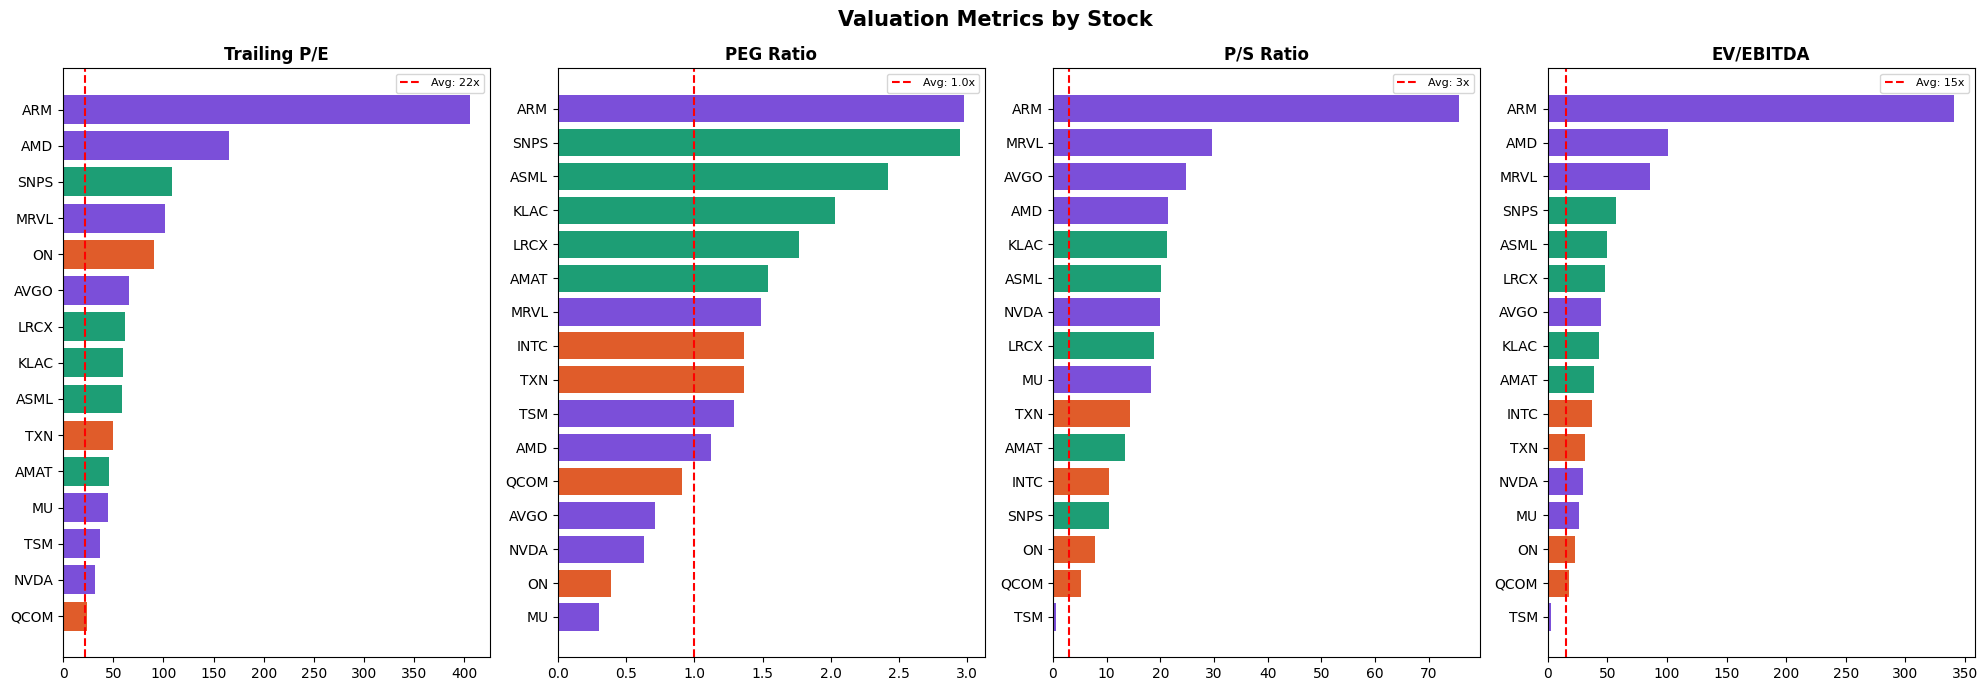

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(20, 7))

metrics    = ['Trailing P/E', 'PEG Ratio', 'P/S Ratio', 'EV/EBITDA']
thresholds = [22, 1.0, 3, 15]   

for ax, metric, threshold in zip(axes, metrics, thresholds):
    data = fund_df[metric].dropna().sort_values()
    colors = ['#7B4FD9' if ticker_group[t] == 'AI Chip Pure Play'
              else '#1D9E75' if ticker_group[t] == 'AI Chip Enabler'
              else '#E05C2A'
              for t in data.index]

    ax.barh(data.index, data.values, color=colors)
    ax.axvline(threshold, color='red', linestyle='--', label=f'Avg: {threshold}x')
    ax.set_title(metric, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Valuation Metrics by Stock', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('layer1_valuation.png', dpi=150)
plt.show()

##### Step 6: Quantify AI Preniunum

In [11]:
# Average each metric by group
group_stats = fund_df.groupby('Group')[
    ['Trailing P/E','PEG Ratio','P/S Ratio','Rev Growth YoY']
].median().round(1)

print(group_stats)

# The key comparison
ai_pe     = group_stats.loc['AI Chip Pure Play', 'Trailing P/E']
ctrl_pe   = group_stats.loc['Non-AI Control',    'Trailing P/E']
ai_grow   = group_stats.loc['AI Chip Pure Play', 'Rev Growth YoY']
ctrl_grow = group_stats.loc['Non-AI Control',    'Rev Growth YoY']

pe_premium     = (ai_pe / ctrl_pe - 1) * 100
growth_premium = (ai_grow / ctrl_grow - 1) * 100

print(f"\nAI stocks trade at a +{pe_premium:.0f}% P/E premium over non-AI controls")
print(f"AI stocks grow revenue {growth_premium:.0f}% faster than non-AI controls")

if growth_premium >= pe_premium:
    print("FINDING: Growth premium ≥ valuation premium → statistically JUSTIFIED")
else:
    print("FINDING: Valuation premium > growth premium → potentially OVERPRICED")

                   Trailing P/E  PEG Ratio  P/S Ratio  Rev Growth YoY
Group                                                                
AI Chip Enabler            60.1        2.0       18.8            13.2
AI Chip Pure Play          65.8        1.1       21.4            37.8
Non-AI Control             50.1        1.1        9.2             6.0

AI stocks trade at a +31% P/E premium over non-AI controls
AI stocks grow revenue 530% faster than non-AI controls
FINDING: Growth premium ≥ valuation premium → statistically JUSTIFIED


In [12]:
def period_return(ticker, start):
    s = prices[ticker].dropna()
    p0 = s.asof(pd.Timestamp(start))
    p1 = s.iloc[-1]
    return round((p1 / p0 - 1) * 100, 1)

returns = pd.DataFrame({
    'Group':           [ticker_group[t] for t in fund_df.index],
    '1Y Return %':     [period_return(t, '2025-06-01') for t in fund_df.index],
    'AI Boom %':       [period_return(t, '2023-01-01') for t in fund_df.index],
    '5Y Return %':     [period_return(t, '2021-01-01') for t in fund_df.index],
}, index=fund_df.index)

spy_1y   = period_return('SPY', '2025-06-01')
spy_boom = period_return('SPY', '2023-01-01')

print(f"SPY 1Y: {spy_1y}%  |  SPY since AI boom: {spy_boom}%")
returns.sort_values('AI Boom %', ascending=False)

SPY 1Y: 26.6%  |  SPY since AI boom: 101.2%


,Group,1Y Return %,AI Boom %,5Y Return %
Ticker,,,,
MU,AI Chip Pure Play,816.9,1654.6,1078.4
NVDA,AI Chip Pure Play,52.0,1306.6,1477.4
LRCX,AI Chip Enabler,278.1,645.5,579.0
AVGO,AI Chip Pure Play,60.6,623.1,881.3
MRVL,AI Chip Pure Play,338.9,620.7,465.7
AMD,AI Chip Pure Play,321.2,620.1,408.5
TSM,AI Chip Pure Play,117.4,485.6,315.2
KLAC,AI Chip Enabler,156.5,428.3,688.4
AMAT,AI Chip Enabler,191.1,379.1,449.5


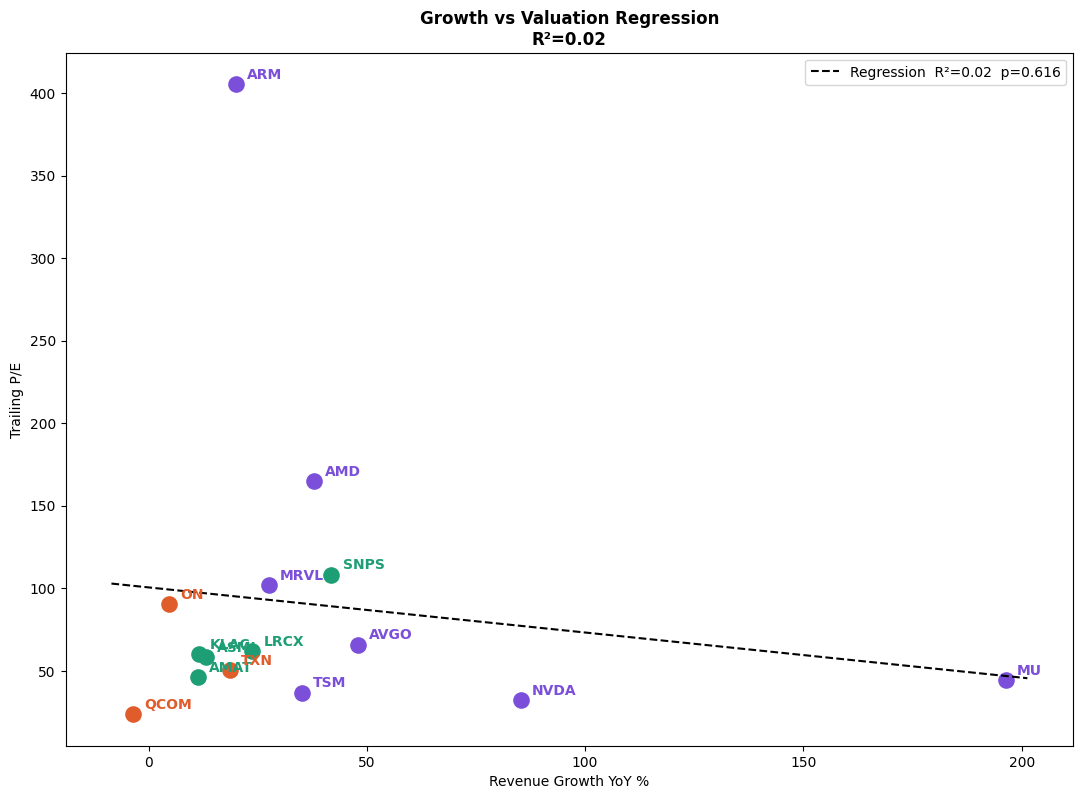

Most overpriced vs growth:
        Trailing P/E  Rev Growth YoY    Residual
Ticker                                          
ARM        405.31396            20.1  310.399364
AMD        165.00674            37.8   74.930600
SNPS       108.22426            41.9   19.268892

Most underpriced vs growth:
        Trailing P/E  Rev Growth YoY   Residual
Ticker                                         
QCOM       23.561222            -3.5 -77.804649
TSM        36.685516            35.1 -54.128694
AMAT       46.154465            11.4 -51.138355


In [19]:
plot_df = fund_df[fund_df['Trailing P/E'].notna() &
                  fund_df['Rev Growth YoY'].notna()].copy()

x = plot_df['Rev Growth YoY'].values
y = plot_df['Trailing P/E'].values

# Fit regression line
slope, intercept, r_value, p_value, _ = stats.linregress(x, y)
r2 = r_value ** 2

# Residuals — how far each stock sits from the line
plot_df['Predicted PE'] = slope * x + intercept
plot_df['Residual']     = y - plot_df['Predicted PE']

# Plot
fig, ax = plt.subplots(figsize=(13, 9))
x_line  = np.linspace(x.min() - 5, x.max() + 5, 100)
ax.plot(x_line, slope * x_line + intercept, '--k',
        label=f'Regression  R²={r2:.2f}  p={p_value:.3f}')

for ticker, row in plot_df.iterrows():
    color = '#7B4FD9' if ticker_group[ticker] == 'AI Chip Pure Play' else \
            '#1D9E75' if ticker_group[ticker] == 'AI Chip Enabler'   else '#E05C2A'
    ax.scatter(row['Rev Growth YoY'], row['Trailing P/E'], color=color, s=120)
    ax.annotate(ticker, (row['Rev Growth YoY'], row['Trailing P/E']),
                xytext=(8, 4), textcoords='offset points',
                fontsize=10, fontweight='bold', color=color)

ax.set_xlabel('Revenue Growth YoY %')
ax.set_ylabel('Trailing P/E')
ax.set_title(f'Growth vs Valuation Regression\nR²={r2:.2f}', fontweight='bold')
ax.legend()
plt.savefig('layer3_regression.png', dpi=150)
plt.show()

# Print the stocks furthest from the line
print("Most overpriced vs growth:")
print(plot_df.nlargest(3, 'Residual')[['Trailing P/E','Rev Growth YoY','Residual']])
print("\nMost underpriced vs growth:")
print(plot_df.nsmallest(3, 'Residual')[['Trailing P/E','Rev Growth YoY','Residual']])

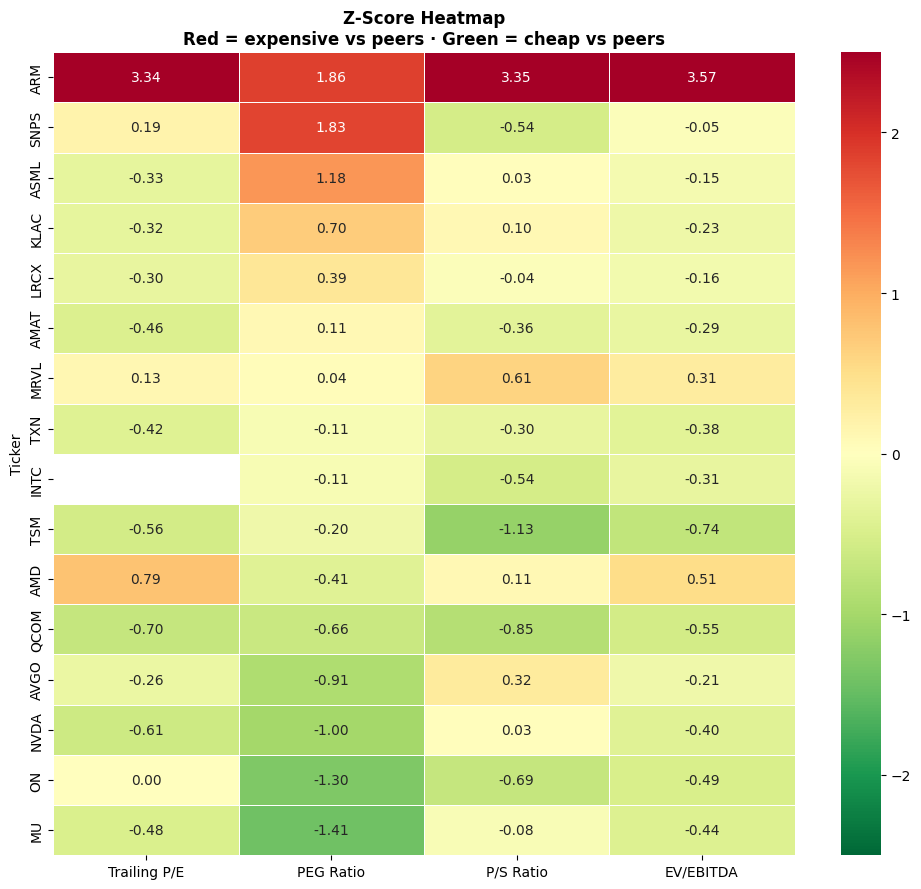

In [20]:
z_metrics = ['Trailing P/E', 'PEG Ratio', 'P/S Ratio', 'EV/EBITDA']
z_df = fund_df[z_metrics].apply(lambda col: (col - col.mean()) / col.std()).round(2)

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(z_df.sort_values('PEG Ratio', ascending=False),
            annot=True, fmt='.2f',
            cmap='RdYlGn_r',   # red = expensive, green = cheap
            center=0, vmin=-2.5, vmax=2.5,
            linewidths=0.5, ax=ax)
ax.set_title('Z-Score Heatmap\nRed = expensive vs peers · Green = cheap vs peers',
             fontweight='bold')
plt.tight_layout()
plt.savefig('layer4_zscores.png', dpi=150)
plt.show()

In [15]:
daily_ret = prices[list(fund_df.index)].pct_change().dropna()
spy_ret   = prices['SPY'].pct_change().dropna()
RF        = 0.045  # risk-free rate

risk_rows = []
for ticker in fund_df.index:
    r          = daily_ret[ticker].dropna()
    ann_ret    = (1 + r.mean()) ** 252 - 1
    ann_vol    = r.std() * np.sqrt(252)
    sharpe     = (ann_ret - RF) / ann_vol
    cum        = (1 + r).cumprod()
    max_dd     = ((cum - cum.cummax()) / cum.cummax()).min() * 100
    aligned    = pd.concat([r, spy_ret], axis=1).dropna()
    beta       = aligned.cov().iloc[0,1] / aligned.iloc[:,1].var()

    risk_rows.append({
        'Ticker':        ticker,
        'Group':         ticker_group[ticker],
        'Ann Return %':  round(ann_ret * 100, 1),
        'Volatility %':  round(ann_vol * 100, 1),
        'Sharpe Ratio':  round(sharpe, 2),
        'Max Drawdown %':round(max_dd, 1),
        'Beta':          round(beta, 2),
    })

risk_df = pd.DataFrame(risk_rows).set_index('Ticker')
risk_df.sort_values('Sharpe Ratio', ascending=False)

,Group,Ann Return %,Volatility %,Sharpe Ratio,Max Drawdown %,Beta
Ticker,,,,,,
MU,AI Chip Pure Play,200.9,60.3,3.26,-57.6,2.24
TSM,AI Chip Pure Play,91.3,39.5,2.20,-36.8,1.65
LRCX,AI Chip Enabler,98.5,47.5,1.98,-47.1,2.11
NVDA,AI Chip Pure Play,95.1,47.6,1.90,-36.9,2.05
AVGO,AI Chip Pure Play,98.8,50.6,1.87,-41.1,2.01
ARM,AI Chip Pure Play,144.4,75.7,1.85,-54.0,2.62
KLAC,AI Chip Enabler,86.2,44.6,1.83,-34.9,1.94
MRVL,AI Chip Pure Play,118.4,64.6,1.76,-60.8,2.42
AMD,AI Chip Pure Play,102.0,57.0,1.71,-63.0,2.21
